# **Kaggle – DataTops®**
Tu TA ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Aspectos importantes
- Última submission:
    - Mañana: 17 de febrero a las 5pm
    - Tarde: 19 de febrero a las 5pm
- **Enlace de la competición**: https://www.kaggle.com/t/c5cc87b50c4b4770bdc8f5acbe15577d
- **Requisito**: Estar registrado en [Kaggle](https://www.kaggle.com/)

## Métrica:
El error cuadrático medio (RMSE, por sus siglas en inglés) es una medida de la desviación estándar de los residuos (errores de predicción). Los residuos representan la diferencia entre los valores observados y los valores predichos por el modelo. El RMSE indica qué tan dispersos están estos errores: cuanto menor es el RMSE, más cercanas están las predicciones a los valores reales. En otras palabras, el RMSE mide qué tan bien se ajusta la línea de regresión a los datos.


$$ RMSE = \sqrt{\frac{1}{n}\Sigma_{i=1}^{n}{\Big(\frac{d_i -f_i}{\sigma_i}\Big)^2}}$$


## 1. Librerías

In [489]:
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import urllib.request

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

## 2. Datos

In [490]:
# Para que funcione necesitas bajarte los archivos de datos de Kaggle
df = pd.read_csv("./data/train.csv", index_col = "laptop_ID")

### 2.1 Exploración de los datos

In [491]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 755 to 229
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           912 non-null    object 
 1   Product           912 non-null    object 
 2   TypeName          912 non-null    object 
 3   Inches            912 non-null    float64
 4   ScreenResolution  912 non-null    object 
 5   Cpu               912 non-null    object 
 6   Ram               912 non-null    object 
 7   Memory            912 non-null    object 
 8   Gpu               912 non-null    object 
 9   OpSys             912 non-null    object 
 10  Weight            912 non-null    object 
 11  Price_in_euros    912 non-null    float64
dtypes: float64(2), object(10)
memory usage: 92.6+ KB


In [492]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
laptop_ID,,,,,,,,,,,,
755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [493]:
df.tail()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
laptop_ID,,,,,,,,,,,,
28,Dell,Inspiron 5570,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg,800.00
1160,HP,Spectre Pro,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.48kg,1629.00
78,Lenovo,IdeaPad 320-15IKBN,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,2TB HDD,Intel HD Graphics 620,No OS,2.2kg,519.00
23,HP,255 G6,Notebook,15.6,1366x768,AMD E-Series E2-9000e 1.5GHz,4GB,500GB HDD,AMD Radeon R2,No OS,1.86kg,258.00
229,Dell,Alienware 17,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,4.42kg,2456.34


In [494]:
df.describe()

,Inches,Price_in_euros
count,912.000000,912.000000
mean,14.981579,1111.724090
std,1.436719,687.959172
min,10.100000,174.000000
25%,14.000000,589.000000
50%,15.600000,978.000000
75%,15.600000,1483.942500
max,18.400000,6099.000000


In [495]:
df.groupby("Company")["Price_in_euros"].mean().sort_values()

Company
Vero          235.400000
Chuwi         246.945000
Mediacom      294.333333
Acer          607.613514
Fujitsu       769.000000
Lenovo       1053.578416
Asus         1068.684050
HP           1093.484639
Dell         1173.998680
Xiaomi       1199.616667
Toshiba      1276.558824
Samsung      1423.000000
Huawei       1424.000000
Apple        1540.322353
MSI          1713.425135
Microsoft    1716.970000
Google       1879.000000
LG           2299.000000
Razer        2987.333333
Name: Price_in_euros, dtype: float64

In [496]:
for col in df.columns:
    print(f"{col} : {df[col].value_counts()}")

Company : Company
Lenovo       202
Dell         197
HP           194
Asus         121
Acer          74
MSI           37
Toshiba       34
Apple         17
Razer          6
Mediacom       6
Samsung        5
Microsoft      5
Xiaomi         3
Huawei         2
Chuwi          2
Google         2
Vero           2
Fujitsu        2
LG             1
Name: count, dtype: int64
Product : Product
XPS 13                                           23
Inspiron 3567                                    22
Legion Y520-15IKBN                               15
Vostro 3568                                      14
ProBook 450                                      13
250 G6                                           13
EliteBook 840                                    12
Satellite Pro                                    10
ThinkPad X1                                      10
Alienware 17                                     10
Inspiron 5570                                    10
MacBook Pro                                

### 2.3 Definir X e y

In [497]:
X = df.drop(['Price_in_euros'], axis=1)
y = df['Price_in_euros'].copy()
X.shape

(912, 11)

In [498]:
y.shape

(912,)

### 2.4 Dividir X_train, X_test, y_train, y_test

In [499]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [500]:
cols = list(X_train.columns)
cols

['Company',
 'Product',
 'TypeName',
 'Inches',
 'ScreenResolution',
 'Cpu',
 'Ram',
 'Memory',
 'Gpu',
 'OpSys',
 'Weight']

In [501]:
X_train[cols[9]].value_counts()

OpSys
Windows 10      596
No OS            39
Linux            37
Windows 7        24
Chrome OS        14
macOS             7
Mac OS X          6
Windows 10 S      5
Android           1
Name: count, dtype: int64

In [502]:
x = X_train[cols[7]].str.split()
print("------------ Un disco ------------")
print(x[(x.str.len() == 2) & ~(x.astype(str).str.contains("Hybrid"))])
print("------------ Un Hybrid ------------")
print(x[(x.str.len() == 2) & (x.astype(str).str.contains("Hybrid"))])
print("------------ Flash Storage ------------")
print(x[x.str.len() == 3])
print("------------ Hibrido ------------")
print(x[x.str.len() == 5])

------------ Un disco ------------
laptop_ID
1118      [1TB, HDD]
153     [512GB, SSD]
275     [512GB, SSD]
1100    [500GB, HDD]
1126    [500GB, HDD]
203     [256GB, SSD]
853     [128GB, SSD]
1244    [256GB, SSD]
819       [1TB, HDD]
438     [256GB, SSD]
296       [1TB, HDD]
831     [512GB, SSD]
326       [1TB, HDD]
543     [256GB, SSD]
1184    [256GB, SSD]
709     [256GB, SSD]
175       [2TB, HDD]
430       [1TB, HDD]
737       [1TB, HDD]
406       [1TB, SSD]
987     [256GB, SSD]
730     [256GB, SSD]
303       [1TB, HDD]
1080    [256GB, SSD]
542     [256GB, SSD]
876     [500GB, HDD]
1104    [500GB, HDD]
535     [500GB, HDD]
83      [512GB, SSD]
598     [512GB, SSD]
477     [512GB, SSD]
1120    [256GB, SSD]
359     [256GB, SSD]
448     [256GB, SSD]
19        [1TB, HDD]
1206    [256GB, SSD]
551     [500GB, HDD]
651       [1TB, HDD]
264     [512GB, SSD]
211     [256GB, SSD]
569     [512GB, SSD]
165     [256GB, SSD]
965     [256GB, SSD]
910       [1TB, HDD]
923     [256GB, SSD]
1153      

In [503]:
x = X_train[cols[8]].str.split()
print("------------ AMD ------------")
mask_amd = X_train[cols[8]].str.contains("AMD", case=False, na=False)
print(x[mask_amd].str.len().value_counts().sort_index())
print(x[x.astype(str).str.contains("AMD")])
print("------------ Nvidia ------------")
mask_amd = X_train[cols[8]].str.contains("Nvidia", case=False, na=False)
print(x[mask_amd].str.len().value_counts().sort_index())
print(x[x.astype(str).str.contains("Nvidia")])
print("------------ Intel ------------")
mask_amd = X_train[cols[8]].str.contains("Intel", case=False, na=False)
print(x[mask_amd].str.len().value_counts().sort_index())
print(x[x.astype(str).str.contains("Intel")])

------------ AMD ------------
Gpu
2     1
3    43
4    48
Name: count, dtype: int64
laptop_ID
1118         [AMD, FirePro, W6150M]
131              [AMD, Radeon, 530]
1126        [AMD, Radeon, R5, M315]
819          [AMD, Radeon, RX, 580]
543              [AMD, Radeon, 530]
709              [AMD, Radeon, 530]
175              [AMD, Radeon, 520]
737              [AMD, Radeon, 520]
303          [AMD, Radeon, R5, 430]
1104              [AMD, Radeon, R5]
535         [AMD, Radeon, R5, M430]
598              [AMD, Radeon, 530]
448              [AMD, Radeon, 530]
551     [AMD, Radeon, R2, Graphics]
910        [AMD, Radeon, R5, M420X]
1153        [AMD, Radeon, R7, M445]
691          [AMD, Radeon, R5, 520]
426          [AMD, Radeon, RX, 550]
671         [AMD, Radeon, R5, M430]
393          [AMD, FirePro, W5130M]
32                [AMD, Radeon, R2]
13          [AMD, Radeon, Pro, 555]
694              [AMD, Radeon, 520]
184              [AMD, Radeon, 530]
935        [AMD, Radeon, R7, M365X]
377   

In [504]:
gpu = X_train["Gpu"].astype(str)

print("---- INTEL ----")
print(gpu[gpu.str.contains("Intel", case=False, na=False)].value_counts().head(30))

print("---- NVIDIA ----")
print(gpu[gpu.str.contains("Nvidia", case=False, na=False)].value_counts().head(30))

print("---- AMD ----")
print(gpu[gpu.str.contains("AMD", case=False, na=False)].value_counts().head(30))


---- INTEL ----
Gpu
Intel HD Graphics 620           150
Intel HD Graphics 520           110
Intel UHD Graphics 620           43
Intel HD Graphics 400            23
Intel HD Graphics 500            20
Intel HD Graphics                18
Intel HD Graphics 515            10
Intel HD Graphics 505             8
Intel HD Graphics 405             7
Intel HD Graphics 615             7
Intel HD Graphics 6000            5
Intel Iris Plus Graphics 640      4
Intel HD Graphics 630             2
Intel HD Graphics 510             2
Intel Iris Graphics 550           1
Intel Iris Graphics 540           1
Intel Iris Plus Graphics 650      1
Intel Graphics 620                1
Intel Iris Pro Graphics           1
Intel HD Graphics 540             1
Intel HD Graphics 620             1
Intel HD Graphics 5300            1
Name: count, dtype: int64
---- NVIDIA ----
Gpu
Nvidia GeForce GTX 1050       32
Nvidia GeForce 940MX          24
Nvidia GeForce GTX 1060       21
Nvidia GeForce GTX 1050 Ti    20
Nvidia Ge

In [505]:
gpu = X_train["Gpu"].astype(str).str.lower()

mask_nvidia = gpu.str.contains("nvidia", na=False)
mask_intel  = gpu.str.contains("intel", na=False)
mask_amd    = gpu.str.contains("amd", na=False)

def etiquetas(series, n=30):
    return (
        series.str.replace(r"[^a-z0-9\s]", " ", regex=True)
              .str.split()
              .explode()
              .value_counts()
              .head(n)
    )

print("NVIDIA")
print(etiquetas(gpu[mask_nvidia], 40))

print("\nAMD")
print(etiquetas(gpu[mask_amd], 40))

print("\nINTEL")
print(etiquetas(gpu[mask_intel], 40))



NVIDIA
Gpu
nvidia     220
geforce    208
gtx        131
1050        52
940mx       31
1060        21
ti          20
1070        20
930mx       18
quadro      12
960m        10
920mx        9
mx150        8
950m         6
980m         6
930m         5
970m         4
m1200        4
gt           4
920m         4
mx130        3
1050m        2
m1000m       2
m2200m       2
m620         2
1080         2
150mx        2
960          2
1050ti       1
m500m        1
980          1
u            1
039c         1
940m         1
m2000m       1
Name: count, dtype: int64

AMD
Gpu
amd         92
radeon      87
r5          30
530         19
m430        15
r7          10
rx           8
520          7
r4           7
r2           6
m445         5
graphics     5
550          4
m330         4
firepro      3
580          3
m420x        2
m440         2
m420         2
w6150m       1
m315         1
430          1
pro          1
555          1
w5130m       1
560          1
m365x        1
m460         1
540      

## 3. Procesado de datos

Nuestro target es la columna `Price_in_euros`

In [506]:
target = "Price_in_euros"

In [507]:
# ------------------------------------------- Product -------------------------------------------
X_train.drop("Product", axis = 1, inplace = True)
X_test.drop("Product", axis = 1, inplace = True)

In [508]:
# ------------------------------------------- CPU -------------------------------------------
def cpu_line(text):
    t = str(text).lower()

    if "intel" in t:
        if "core i3" in t: return "intel_i3"
        if "core i5" in t: return "intel_i5"
        if "core i7" in t: return "intel_i7"
        if "xeon" in t: return "intel_xeon"
        if "celeron" in t: return "intel_celeron"
        if "pentium" in t: return "intel_pentium"
        if "atom" in t: return "intel_atom"
        if "core m" in t: return "intel_core_m"
        return "intel_other"

    if "amd" in t:
        if "ryzen" in t: return "amd_ryzen"
        if any(x in t for x in ["a12", "a10", "a9", "a8", "a6"]):
            return "amd_a_series"
        if "e-series" in t or "e2-" in t:
            return "amd_e_series"
        if "fx" in t:
            return "amd_fx"
        return "amd_other"

    return "other"


In [509]:
# ------------------------------------------- CPU -------------------------------------------
for X in [X_train, X_test]:
    X["cpu_is_intel"] = X["Cpu"].str.contains("Intel", case=False, na=False).astype(int)
    X["cpu_is_amd"]   = X["Cpu"].str.contains("AMD",   case=False, na=False).astype(int)

    X["cpu_ghz"] = (
        X["Cpu"]
        .str.extract(r"(\d+(?:\.\d+)?)\s*GHz", expand=False)
        .astype(float)
    )

    X["cpu_modelo"] = X["Cpu"].apply(cpu_line)

    X.drop(columns=["Cpu"], inplace=True)


X_train = pd.get_dummies(X_train, columns=["cpu_modelo"], dtype=int)
X_test  = pd.get_dummies(X_test,  columns=["cpu_modelo"], dtype=int)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


In [510]:
def to_gb(s):
    s = s.upper()
    if "TB" in s:
        return float(s.replace("TB", "")) * 1024
    return float(s.replace("GB", ""))

def len2(train_test, col="Memory"):
    x = train_test[col].str.split()

    mask = x.str.len() == 2

    size = x[mask].str[0]
    typ  = x[mask].str[1]

    gb = size.apply(to_gb)

    train_test.loc[mask & (typ == "SSD"), "memory_ssd_gb"] = gb
    train_test.loc[mask & (typ == "HDD"), "memory_hdd_gb"] = gb

def flash(train_test, col="Memory"):
    x = train_test[col].str.split()

    mask = x.str.len() == 3

    size = x[mask].str[0]
    gb = size.apply(to_gb)

    train_test.loc[mask, "memory_flash_gb"] = gb
    
def hybrid_len2(train_test, col="Memory"):
    x = train_test[col].str.split()

    mask = (x.str.len() == 2) & (x.astype(str).str.contains("Hybrid"))

    size = x[mask].str[0]
    gb = size.apply(to_gb)

    train_test.loc[mask, "memory_hybrid_gb"] = gb

def len5(train_test, col="Memory"):
    x = train_test[col].str.split()

    mask = x.str.len() == 5

    size1 = x[mask].str[0]
    type1 = x[mask].str[1]

    size2 = x[mask].str[3]
    type2 = x[mask].str[4]

    gb1 = size1.apply(to_gb)
    gb2 = size2.apply(to_gb)

    train_test.loc[mask & (type1 == "SSD"), "memory_ssd_gb"] += gb1
    train_test.loc[mask & (type1 == "HDD"), "memory_hdd_gb"] += gb1

    train_test.loc[mask & (type2 == "SSD"), "memory_ssd_gb"] += gb2
    train_test.loc[mask & (type2 == "HDD"), "memory_hdd_gb"] += gb2


In [511]:
# ------------------------------------------- Memory -------------------------------------------

col = "Memory"

for train_test in [X_train, X_test]:
    train_test["memory_ssd_gb"] = 0
    train_test["memory_hdd_gb"] = 0
    train_test["memory_flash_gb"] = 0
    train_test["memory_hybrid_gb"] = 0

for train_test in [X_train, X_test]:
    hybrid_len2(train_test, col="Memory")
    len2(train_test, col="Memory")
    flash(train_test, col="Memory")    
    len5(train_test, col="Memory")    

    train_test["memory_total_gb"] = (
        train_test["memory_ssd_gb"] +
        train_test["memory_hdd_gb"] +
        train_test["memory_flash_gb"] +
        train_test["memory_hybrid_gb"]
    )

X_train.drop("Memory", axis = 1, inplace = True)
X_test.drop("Memory", axis = 1, inplace = True)


In [512]:
# ------------------------------------------- Gpu -------------------------------------------
import numpy as np
import pandas as pd
import re

def gpu(df, col="Gpu"):
    s = df[col].astype(str).str.lower()

    df["gpu_is_intel"]  = s.str.contains("intel").astype(int)
    df["gpu_is_nvidia"] = s.str.contains("nvidia").astype(int)
    df["gpu_is_amd"]    = s.str.contains("amd").astype(int)

    df["gpu_num"] = (
        s.str.extract(r"(\d{3,4})", expand=False)
         .astype(float)
    )

    df["gpu_has_letters"] = s.str.contains(r"\d+[a-z]+|[a-z]+\d+", regex=True).astype(int)

    df["gpu_num"] = df["gpu_num"].fillna(df["gpu_num"].median())

    df.drop(columns=[col], inplace=True)

    return df


In [513]:
# ------------------------------------------- Gpu -------------------------------------------
X_train = gpu(X_train, col="Gpu")
X_test = gpu(X_test, col="Gpu")

In [514]:
# ------------------------------------------- RAM -------------------------------------------
X_train["Ram_GB"] = X_train["Ram"].str.replace("GB", "").astype(int)
X_test["Ram_GB"] = X_test["Ram"].str.replace("GB", "").astype(int)

X_train.drop("Ram", axis = 1, inplace = True)
X_test.drop("Ram", axis = 1, inplace = True)

In [515]:
# ------------------------------------------- Weight -------------------------------------------
X_train["Weight_KG"] = X_train["Weight"].str.replace("kg", "").astype(float)
X_test["Weight_KG"] = X_test["Weight"].str.replace("kg", "").astype(float)

X_train.drop("Weight", axis = 1, inplace = True)
X_test.drop("Weight", axis = 1, inplace = True)

In [516]:
# ------------------------------------------- ScreenResolution -------------------------------------------
res = X_train["ScreenResolution"].str.extract(r"(\d+)\s*x\s*(\d+)")
X_train["screen_width"] = res[0].astype(float)
X_train["screen_height"] = res[1].astype(float)

X_train["pixel_count"] = X_train["screen_width"] * X_train["screen_height"]

res = X_test["ScreenResolution"].str.extract(r"(\d+)\s*x\s*(\d+)")
X_test["screen_width"] = res[0].astype(float)
X_test["screen_height"] = res[1].astype(float)

X_test["pixel_count"] = X_test["screen_width"] * X_test["screen_height"]

X_train.drop("ScreenResolution", axis = 1, inplace = True)
X_test.drop("ScreenResolution", axis = 1, inplace = True)

In [517]:
cat_ohe = ["TypeName", "Company", "OpSys"]

X_train = pd.get_dummies(X_train, columns=cat_ohe, dtype=int)
X_test  = pd.get_dummies(X_test,  columns=cat_ohe, dtype=int)

# Alinear columnas (muy importante)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


In [518]:
X_train.columns

Index(['Inches', 'cpu_is_intel', 'cpu_is_amd', 'cpu_ghz',
       'cpu_modelo_amd_a_series', 'cpu_modelo_amd_e_series',
       'cpu_modelo_amd_fx', 'cpu_modelo_amd_ryzen', 'cpu_modelo_intel_atom',
       'cpu_modelo_intel_celeron', 'cpu_modelo_intel_core_m',
       'cpu_modelo_intel_i3', 'cpu_modelo_intel_i5', 'cpu_modelo_intel_i7',
       'cpu_modelo_intel_pentium', 'cpu_modelo_intel_xeon', 'memory_ssd_gb',
       'memory_hdd_gb', 'memory_flash_gb', 'memory_hybrid_gb',
       'memory_total_gb', 'gpu_is_intel', 'gpu_is_nvidia', 'gpu_is_amd',
       'gpu_num', 'gpu_has_letters', 'Ram_GB', 'Weight_KG', 'screen_width',
       'screen_height', 'pixel_count', 'TypeName_2 in 1 Convertible',
       'TypeName_Gaming', 'TypeName_Netbook', 'TypeName_Notebook',
       'TypeName_Ultrabook', 'TypeName_Workstation', 'Company_Acer',
       'Company_Apple', 'Company_Asus', 'Company_Chuwi', 'Company_Dell',
       'Company_Fujitsu', 'Company_Google', 'Company_HP', 'Company_Lenovo',
       'Company_MSI', 

In [519]:
len(X_train.columns)

63

In [520]:
X_train.head()

,Inches,cpu_is_intel,cpu_is_amd,cpu_ghz,cpu_modelo_amd_a_series,cpu_modelo_amd_e_series,cpu_modelo_amd_fx,cpu_modelo_amd_ryzen,cpu_modelo_intel_atom,cpu_modelo_intel_celeron,cpu_modelo_intel_core_m,cpu_modelo_intel_i3,cpu_modelo_intel_i5,cpu_modelo_intel_i7,cpu_modelo_intel_pentium,cpu_modelo_intel_xeon,memory_ssd_gb,memory_hdd_gb,memory_flash_gb,memory_hybrid_gb,memory_total_gb,gpu_is_intel,gpu_is_nvidia,gpu_is_amd,gpu_num,gpu_has_letters,Ram_GB,Weight_KG,screen_width,screen_height,pixel_count,TypeName_2 in 1 Convertible,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,Company_Acer,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,Company_Google,Company_HP,Company_Lenovo,Company_MSI,Company_Mediacom,Company_Microsoft,Company_Razer,Company_Samsung,Company_Toshiba,Company_Vero,Company_Xiaomi,OpSys_Android,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
laptop_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1118,17.3,1,0,2.6,0,0,0,0,0,0,0,0,0,1,0,0,0,1024,0,0,1024,0,0,1,6150.0,1,8,3.00,1920.0,1080.0,2073600.0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
153,15.6,1,0,2.8,0,0,0,0,0,0,0,0,0,1,0,0,512,0,0,0,512,0,1,0,1050.0,0,16,2.56,1920.0,1080.0,2073600.0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
275,13.3,1,0,2.9,0,0,0,0,0,0,0,0,1,0,0,0,512,0,0,0,512,1,0,0,550.0,0,8,1.37,2560.0,1600.0,4096000.0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1100,14.0,1,0,2.3,0,0,0,0,0,0,0,0,1,0,0,0,0,500,0,0,500,1,0,0,520.0,0,4,1.54,1920.0,1080.0,2073600.0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
131,17.3,1,0,1.8,0,0,0,0,0,0,0,0,0,1,0,0,256,2048,0,0,2304,0,0,1,530.0,0,16,2.80,1920.0,1080.0,2073600.0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [521]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 1118 to 418
Data columns (total 63 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Inches                       729 non-null    float64
 1   cpu_is_intel                 729 non-null    int64  
 2   cpu_is_amd                   729 non-null    int64  
 3   cpu_ghz                      729 non-null    float64
 4   cpu_modelo_amd_a_series      729 non-null    int64  
 5   cpu_modelo_amd_e_series      729 non-null    int64  
 6   cpu_modelo_amd_fx            729 non-null    int64  
 7   cpu_modelo_amd_ryzen         729 non-null    int64  
 8   cpu_modelo_intel_atom        729 non-null    int64  
 9   cpu_modelo_intel_celeron     729 non-null    int64  
 10  cpu_modelo_intel_core_m      729 non-null    int64  
 11  cpu_modelo_intel_i3          729 non-null    int64  
 12  cpu_modelo_intel_i5          729 non-null    int64  
 13  cpu_modelo_intel_i7   

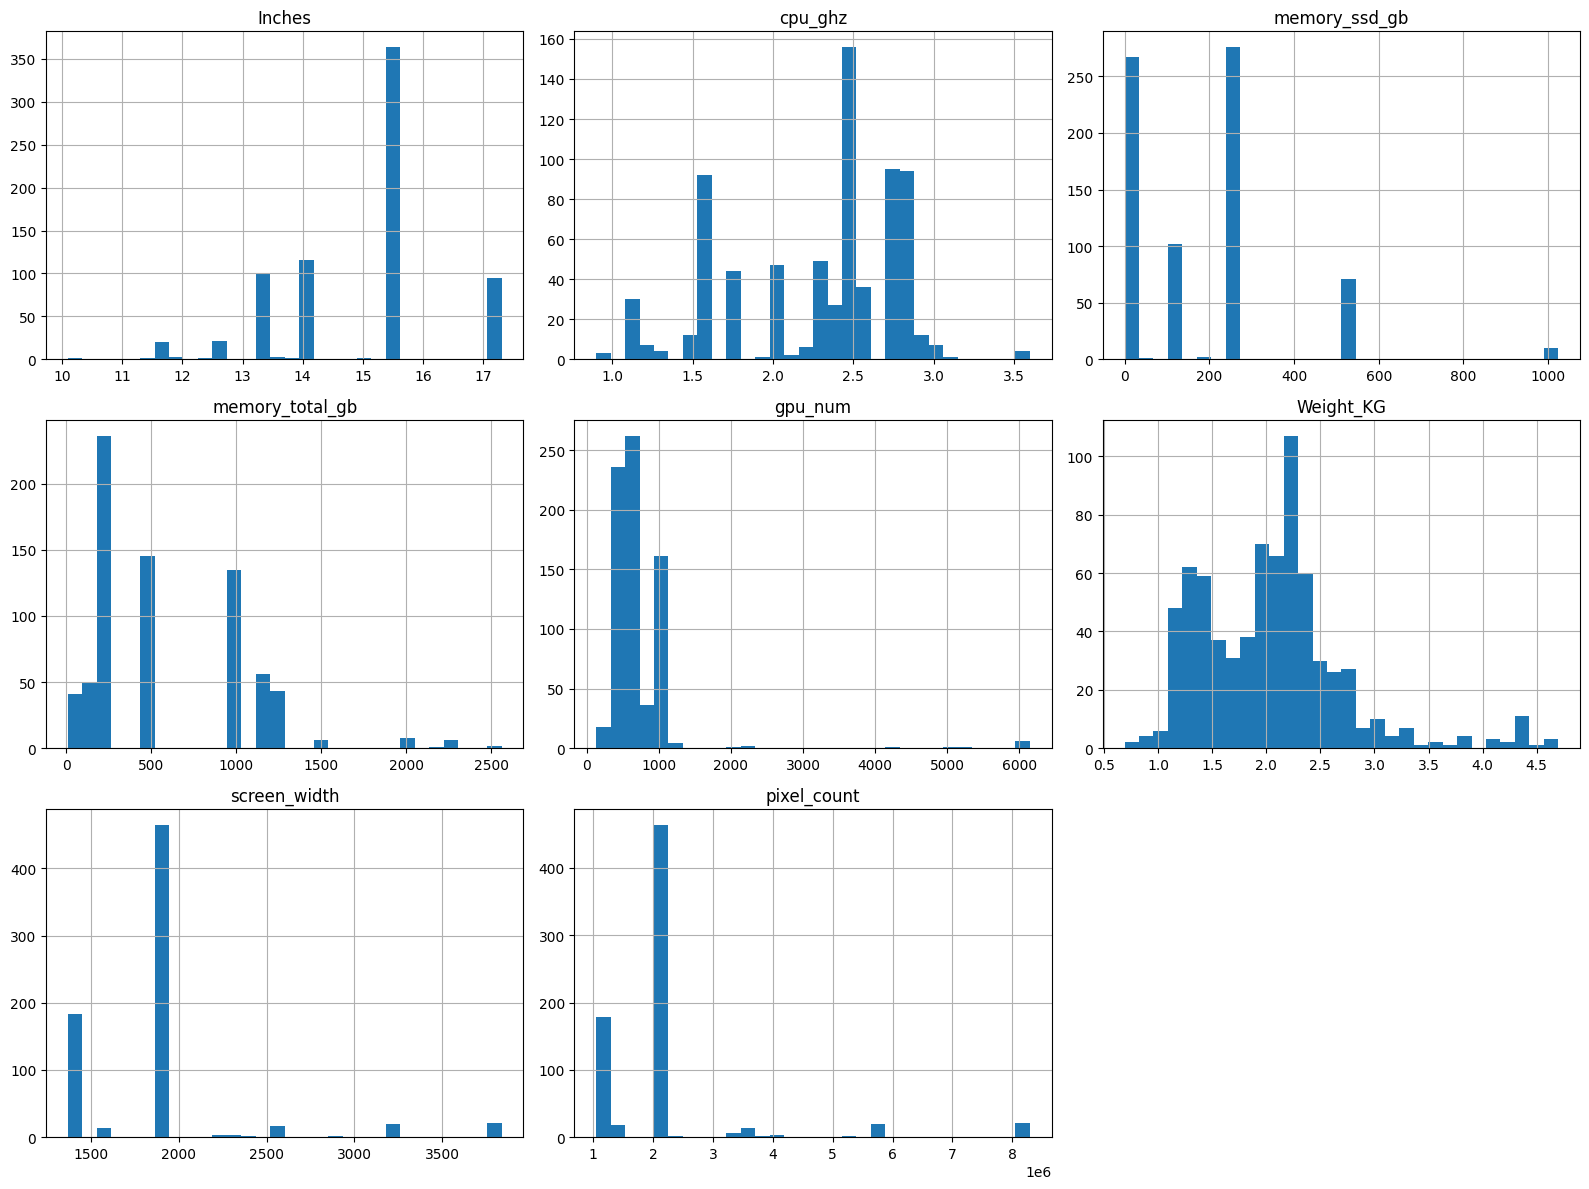

In [522]:
import matplotlib.pyplot as plt

# Selecciona SOLO columnas continuas (float + ints que no sean binarias)
cont_cols = []

for col in X_train.columns:
    if X_train[col].nunique() > 10:   # umbral típico
        cont_cols.append(col)

X_train[cont_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()


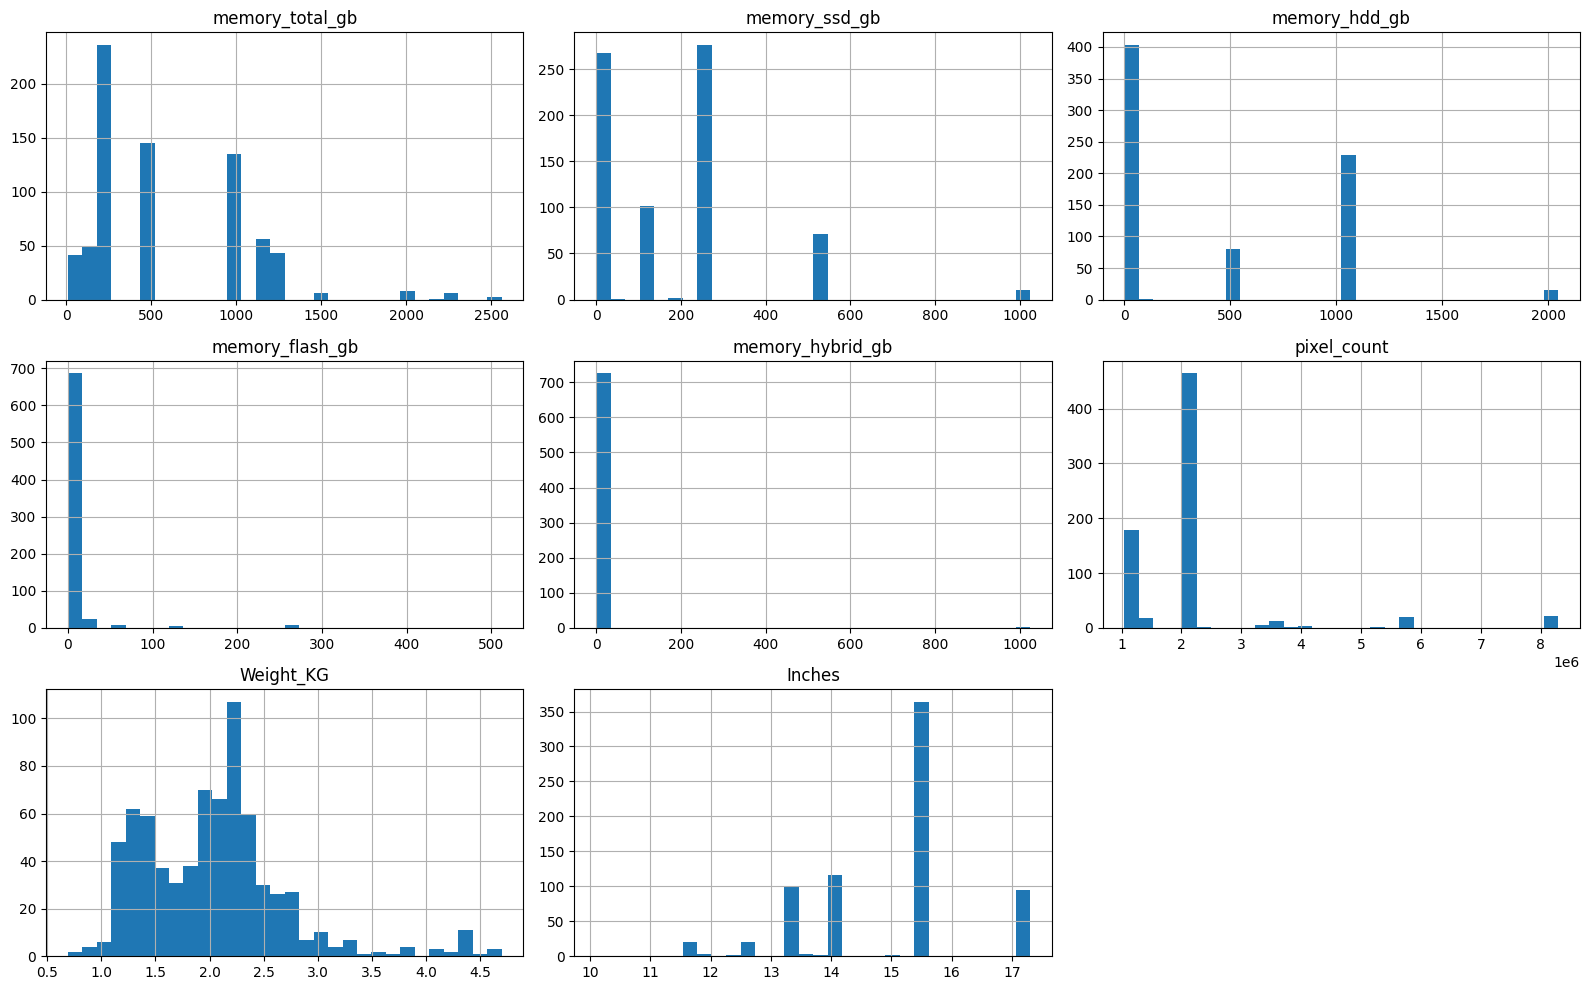

In [523]:
log_candidates = [
    "memory_total_gb",
    "memory_ssd_gb",
    "memory_hdd_gb",
    "memory_flash_gb",
    "memory_hybrid_gb",
    "pixel_count",
    "Weight_KG",
    "Inches"
]

X_train[log_candidates].hist(figsize=(16, 10), bins=30)
plt.tight_layout()
plt.show()

-----------------------------------------------------------------------------------------------------------------

## 4. Modelado

### 4.1 Baseline de modelos


In [524]:
from sklearn.model_selection import GridSearchCV
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [20, 40, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5],
    "bootstrap": [True]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE CV:", -grid.best_score_)

best_rf = grid.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores hiperparámetros: {'bootstrap': True, 'max_depth': 40, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Mejor RMSE CV: 272.00165570040224


In [535]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(random_state=42, n_jobs=-1, objective="reg:squarederror")

param_grid_1 = {
    "n_estimators": [300, 600, 1000],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0],
    "reg_alpha": [0, 0.1],
    "reg_lambda": [1, 3]
}

param_grid_2 = {
    "n_estimators": [300, 600, 700],
    "learning_rate": [0.03, 0.05, 0.07],
    "max_depth": [3, 4, 5],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.9],
    "min_child_weight": [1, 3, 5],
    "reg_lambda": [1, 3, 5],
}

param_grid_4 = {
    # Boosting
    "n_estimators": [600, 900, 1200],
    "learning_rate": [0.02, 0.03, 0.05],

    # Tree complexity
    "max_depth": [3, 4, 5],
    "min_child_weight": [1, 3, 5],

    # Regularización (CLAVE para tu caso)
    "reg_alpha": [0, 0.1, 0.5, 1],
    "reg_lambda": [1, 2, 3, 5],

    # Sampling (CLAVE anti-overfit)
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_2,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)


param_grid_3 = {
    "n_estimators": [300, 500, 700, 1000, 1300],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08],

    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 2, 3, 5, 8, 12],
    "gamma": [0, 0.1, 0.3, 0.5, 1.0, 2.0],

    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],

    "reg_alpha": [0, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
    "reg_lambda": [1, 2, 3, 5, 7, 10, 15, 25],
}

# search = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=param_grid_3,
#     n_iter=60,
#     scoring="neg_root_mean_squared_error",
#     cv=5,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )


grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE CV:", -grid.best_score_)

best_xgb = grid.best_estimator_


Fitting 5 folds for each of 2187 candidates, totalling 10935 fits
Mejores hiperparámetros: {'colsample_bytree': 0.5, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 700, 'reg_lambda': 3, 'subsample': 0.8}
Mejor RMSE CV: 248.6794335680122


In [526]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV

lgbm = LGBMRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [200, 500],
    "learning_rate": [0.03, 0.05],
    "max_depth": [-1, 6],
    "num_leaves": [31, 63],
    "min_child_samples": [10, 20],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}
xgb = XGBRegressor(    random_state=42, n_jobs=-1, objective="reg:squarederror")

grid = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE CV:", -grid.best_score_)

best_lgbm = grid.best_estimator_


Fitting 5 folds for each of 128 candidates, totalling 640 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000718 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 281
[LightGBM] [Info] Number of data points in the train set: 729, number of used features: 39
[LightGBM] [Info] Start training from score 1103.789314
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [527]:
# from catboost import CatBoostRegressor
# from sklearn.model_selection import GridSearchCV

# cat = CatBoostRegressor(
#     random_state=42,
#     verbose=0
# )

# param_grid = {
#     "iterations": [500, 1000],
#     "depth": [4, 6, 8],
#     "learning_rate": [0.03, 0.05, 0.1],
#     "l2_leaf_reg": [1, 3, 5, 9]
# }

# grid = GridSearchCV(
#     estimator=cat,
#     param_grid=param_grid,
#     scoring="neg_root_mean_squared_error",
#     cv=5,
#     n_jobs=-1,
#     verbose=1
# )

# grid.fit(X_train, y_train)

# print("Mejores hiperparámetros:", grid.best_params_)
# print("Mejor RMSE CV:", -grid.best_score_)

# best_cat = grid.best_estimator_


### 4.2 Sacar métricas, valorar los modelos

Recuerda que en la competición se va a evaluar con la métrica de ``RMSE``.

In [ ]:

from sklearn.metrics import root_mean_squared_error

for name, model in [
    ("XGB", best_xgb),
    ("LGBM", best_lgbm),
    ("RF", best_rf)
]:
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    rmse_test = root_mean_squared_error(y_test, y_pred_test)

    print(f"{name} -> RMSE train: {rmse_train:.3f} | RMSE test: {rmse_test:.3f}")


XGB -> RMSE train: 141.975 | RMSE test: 310.661
LGBM -> RMSE train: 139.452 | RMSE test: 349.888
RF -> RMSE train: 108.220 | RMSE test: 376.653


In [ ]:

from sklearn.metrics import root_mean_squared_error

for name, model in [
    ("XGB", best_xgb),
    ("LGBM", best_lgbm),
    ("RF", best_rf)
]:
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    rmse_test = root_mean_squared_error(y_test, y_pred_test)

    print(f"{name} -> RMSE train: {rmse_train:.3f} | RMSE test: {rmse_test:.3f}")


XGB -> RMSE train: 137.522 | RMSE test: 296.885
LGBM -> RMSE train: 139.452 | RMSE test: 306.831
RF -> RMSE train: 108.220 | RMSE test: 308.250


In [ ]:

from sklearn.metrics import root_mean_squared_error

for name, model in [
    ("XGB", best_xgb),
    ("LGBM", best_lgbm),
    ("RF", best_rf)
]:
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    rmse_test = root_mean_squared_error(y_test, y_pred_test)

    print(f"{name} -> RMSE train: {rmse_train:.3f} | RMSE test: {rmse_test:.3f}")


XGB -> RMSE train: 121.572 | RMSE test: 297.549
LGBM -> RMSE train: 139.452 | RMSE test: 306.831
RF -> RMSE train: 108.220 | RMSE test: 308.250


In [ ]:

from sklearn.metrics import root_mean_squared_error

for name, model in [
    ("XGB", best_xgb),
    ("LGBM", best_lgbm),
    ("RF", best_rf)
]:
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    rmse_test = root_mean_squared_error(y_test, y_pred_test)

    print(f"{name} -> RMSE train: {rmse_train:.3f} | RMSE test: {rmse_test:.3f}")


XGB -> RMSE train: 127.482 | RMSE test: 294.407
LGBM -> RMSE train: 139.452 | RMSE test: 306.831
RF -> RMSE train: 108.220 | RMSE test: 308.250


In [106]:

from sklearn.metrics import root_mean_squared_error

for name, model in [
    ("XGB", best_xgb),
    ("LGBM", best_lgbm),
    ("RF", best_rf)
]:
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    rmse_test = root_mean_squared_error(y_test, y_pred_test)

    print(f"{name} -> RMSE train: {rmse_train:.3f} | RMSE test: {rmse_test:.3f}")


XGB -> RMSE train: 125.905 | RMSE test: 290.333
LGBM -> RMSE train: 136.460 | RMSE test: 306.022
RF -> RMSE train: 107.190 | RMSE test: 312.799


In [195]:

from sklearn.metrics import root_mean_squared_error

for name, model in [
    ("XGB", best_xgb),
    ("LGBM", best_lgbm),
    ("RF", best_rf)
]:
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    rmse_test = root_mean_squared_error(y_test, y_pred_test)

    print(f"{name} -> RMSE train: {rmse_train:.3f} | RMSE test: {rmse_test:.3f}")


XGB -> RMSE train: 125.905 | RMSE test: 290.333
LGBM -> RMSE train: 136.460 | RMSE test: 305.973
RF -> RMSE train: 107.209 | RMSE test: 313.062


In [315]:

from sklearn.metrics import root_mean_squared_error

for name, model in [
    ("XGB", best_xgb),
    ("LGBM", best_lgbm),
    ("RF", best_rf)
]:
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    rmse_test = root_mean_squared_error(y_test, y_pred_test)

    print(f"{name} -> RMSE train: {rmse_train:.3f} | RMSE test: {rmse_test:.3f}")


XGB -> RMSE train: 79.774 | RMSE test: 270.695
LGBM -> RMSE train: 116.171 | RMSE test: 296.787
RF -> RMSE train: 100.096 | RMSE test: 304.230


In [422]:

from sklearn.metrics import root_mean_squared_error

for name, model in [
    ("XGB", best_xgb),
    ("LGBM", best_lgbm),
    ("RF", best_rf)
]:
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    rmse_test = root_mean_squared_error(y_test, y_pred_test)

    print(f"{name} -> RMSE train: {rmse_train:.3f} | RMSE test: {rmse_test:.3f}")


XGB -> RMSE train: 142.923 | RMSE test: 289.374
LGBM -> RMSE train: 135.291 | RMSE test: 304.376
RF -> RMSE train: 108.096 | RMSE test: 304.090


In [487]:

from sklearn.metrics import root_mean_squared_error

for name, model in [
    ("XGB", best_xgb),
    ("LGBM", best_lgbm),
    ("RF", best_rf)
]:
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    rmse_test = root_mean_squared_error(y_test, y_pred_test)

    print(f"{name} -> RMSE train: {rmse_train:.3f} | RMSE test: {rmse_test:.3f}")


XGB -> RMSE train: 127.921 | RMSE test: 275.161
LGBM -> RMSE train: 128.687 | RMSE test: 297.324
RF -> RMSE train: 106.363 | RMSE test: 303.243


In [528]:

from sklearn.metrics import root_mean_squared_error

for name, model in [
    ("XGB", best_xgb),
    ("LGBM", best_lgbm),
    ("RF", best_rf)
]:
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    rmse_test = root_mean_squared_error(y_test, y_pred_test)

    print(f"{name} -> RMSE train: {rmse_train:.3f} | RMSE test: {rmse_test:.3f}")


XGB -> RMSE train: 79.774 | RMSE test: 270.695
LGBM -> RMSE train: 116.171 | RMSE test: 296.787
RF -> RMSE train: 100.096 | RMSE test: 304.230


In [537]:

from sklearn.metrics import root_mean_squared_error

for name, model in [
    ("XGB", best_xgb),
    ("LGBM", best_lgbm),
    ("RF", best_rf)
]:
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    rmse_test = root_mean_squared_error(y_test, y_pred_test)

    print(f"{name} -> RMSE train: {rmse_train:.3f} | RMSE test: {rmse_test:.3f}")


XGB -> RMSE train: 87.124 | RMSE test: 267.421
LGBM -> RMSE train: 116.171 | RMSE test: 296.787
RF -> RMSE train: 100.096 | RMSE test: 304.230


In [538]:

importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(20)

TypeName_Notebook           0.194943
Ram_GB                      0.161147
cpu_modelo_intel_i7         0.100116
TypeName_Gaming             0.045950
memory_ssd_gb               0.044689
pixel_count                 0.041341
OpSys_Windows 7             0.030799
TypeName_Workstation        0.026967
cpu_modelo_intel_celeron    0.025079
cpu_modelo_intel_i5         0.024479
gpu_num                     0.023129
Inches                      0.021939
screen_height               0.020157
cpu_modelo_intel_i3         0.018735
cpu_ghz                     0.018455
Weight_KG                   0.016452
screen_width                0.015300
OpSys_No OS                 0.014920
TypeName_Ultrabook          0.012328
cpu_modelo_amd_a_series     0.010934
dtype: float32

### 4.3 Optimización (up to you 🫰🏻)

-----------------------------------------------------------------

## Una vez listo el modelo, toca predecir ``test.csv``

**RECUERDA: APLICAR LAS TRANSFORMACIONES QUE HAYAS REALIZADO EN `train.csv` a `test.csv`.**


Véase:
- Estandarización/Normalización
- Eliminación de Outliers
- Eliminación de columnas
- Creación de columnas nuevas
- Gestión de valores nulos
- Y un largo etcétera de técnicas que como Data Scientist hayas considerado las mejores para tu dataset.

## 1. Carga los datos de `test.csv` para predecir.


In [539]:
X_pred = pd.read_csv("./data/test.csv", index_col="laptop_ID")
X_pred.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
laptop_ID,,,,,,,,,,,
209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


In [540]:
X_pred.tail()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
laptop_ID,,,,,,,,,,,
820,MSI,GE72MVR 7RG,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,2.9kg
948,Toshiba,Tecra Z40-C-12X,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.47kg
483,Dell,Precision M5520,Workstation,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg
1017,HP,Probook 440,Notebook,14.0,1366x768,Intel Core i5 7200U 2.5GHz,4GB,500GB HDD,Intel HD Graphics 620,Windows 10,1.64kg
421,Asus,ZenBook Flip,2 in 1 Convertible,13.3,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.27kg


In [541]:
X_pred.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391 entries, 209 to 421
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           391 non-null    object 
 1   Product           391 non-null    object 
 2   TypeName          391 non-null    object 
 3   Inches            391 non-null    float64
 4   ScreenResolution  391 non-null    object 
 5   Cpu               391 non-null    object 
 6   Ram               391 non-null    object 
 7   Memory            391 non-null    object 
 8   Gpu               391 non-null    object 
 9   OpSys             391 non-null    object 
 10  Weight            391 non-null    object 
dtypes: float64(1), object(10)
memory usage: 36.7+ KB


 ## 2. Replicar el procesado para ``test.csv``

In [542]:
# ------------------------------------------- Product -------------------------------------------
X_pred.drop("Product", axis = 1, inplace = True)

In [543]:
# ------------------------------------------- CPU -------------------------------------------

X_pred["cpu_is_intel"] = X_pred["Cpu"].str.contains("Intel", case=False, na=False).astype(int)
X_pred["cpu_is_amd"]   = X_pred["Cpu"].str.contains("AMD",   case=False, na=False).astype(int)

X_pred["cpu_ghz"] = (
    X_pred["Cpu"]
    .str.extract(r"(\d+(?:\.\d+)?)\s*GHz", expand=False)
    .astype(float)
)

X_pred["cpu_modelo"] = X_pred["Cpu"].apply(cpu_line)

X_pred.drop(columns=["Cpu"], inplace=True)


X_pred = pd.get_dummies(X_pred, columns=["cpu_modelo"], dtype=int)

In [544]:
# ------------------------------------------- Memory -------------------------------------------

col = "Memory"

X_pred["memory_ssd_gb"] = 0
X_pred["memory_hdd_gb"] = 0
X_pred["memory_flash_gb"] = 0
X_pred["memory_hybrid_gb"] = 0

hybrid_len2(X_pred, col="Memory")
len2(X_pred, col="Memory")
flash(X_pred, col="Memory")    
len5(X_pred, col="Memory")    

X_pred["memory_total_gb"] = (
    X_pred["memory_ssd_gb"] +
    X_pred["memory_hdd_gb"] +
    X_pred["memory_flash_gb"] +
    X_pred["memory_hybrid_gb"]
)

X_pred.drop("Memory", axis = 1, inplace = True)


In [545]:
# ------------------------------------------- Gpu -------------------------------------------
X_pred = gpu(X_pred, col="Gpu")

In [546]:
# ------------------------------------------- RAM -------------------------------------------
X_pred["Ram_GB"] = X_pred["Ram"].str.replace("GB", "").astype(int)

X_pred.drop("Ram", axis = 1, inplace = True)

In [547]:
# ------------------------------------------- Weight -------------------------------------------
X_pred["Weight_KG"] = X_pred["Weight"].str.replace("kg", "").astype(float)

X_pred.drop("Weight", axis = 1, inplace = True)

In [548]:
# ------------------------------------------- ScreenResolution -------------------------------------------
res = X_pred["ScreenResolution"].str.extract(r"(\d+)\s*x\s*(\d+)")
X_pred["screen_width"] = res[0].astype(float)
X_pred["screen_height"] = res[1].astype(float)

X_pred["pixel_count"] = X_pred["screen_width"] * X_pred["screen_height"]

X_pred.drop("ScreenResolution", axis = 1, inplace = True)

In [549]:
at_ohe = ["TypeName", "Company", "OpSys"]

X_pred = pd.get_dummies(X_pred, columns=cat_ohe, dtype=int)

X_pred = X_pred.reindex(columns=X_train.columns, fill_value=0)


In [550]:
X_pred.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391 entries, 209 to 421
Data columns (total 63 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Inches                       391 non-null    float64
 1   cpu_is_intel                 391 non-null    int64  
 2   cpu_is_amd                   391 non-null    int64  
 3   cpu_ghz                      391 non-null    float64
 4   cpu_modelo_amd_a_series      391 non-null    int64  
 5   cpu_modelo_amd_e_series      391 non-null    int64  
 6   cpu_modelo_amd_fx            391 non-null    int64  
 7   cpu_modelo_amd_ryzen         391 non-null    int64  
 8   cpu_modelo_intel_atom        391 non-null    int64  
 9   cpu_modelo_intel_celeron     391 non-null    int64  
 10  cpu_modelo_intel_core_m      391 non-null    int64  
 11  cpu_modelo_intel_i3          391 non-null    int64  
 12  cpu_modelo_intel_i5          391 non-null    int64  
 13  cpu_modelo_intel_i7    

In [551]:
predictions_submit = best_xgb.predict(X_pred)
predictions_submit

array([1662.126  ,  293.79492,  360.21973,  963.1434 , 1000.2397 ,
        393.6624 ,  747.8893 ,  996.6226 , 1103.1913 ,  261.27478,
       2199.7542 , 1431.8567 ,  457.34418, 1634.9183 ,  870.0771 ,
        651.35535, 2055.11   , 1231.3091 , 2151.48   ,  650.2225 ,
       1566.9712 ,  279.6021 ,  756.0156 , 1042.3474 ,  493.74698,
        718.1835 ,  535.405  , 1100.3047 , 2824.5159 , 1103.9578 ,
       2378.2505 ,  390.84222,  873.0678 , 2990.6824 , 2178.0552 ,
       1580.6115 ,  652.8816 , 1142.7488 ,  977.64606, 1639.4558 ,
        534.3586 ,  755.6943 ,  532.5136 , 1260.1061 , 1181.8634 ,
       1073.5424 , 1068.0747 ,  563.96906,  651.3961 ,  466.92648,
       1798.1758 ,  727.7594 , 1139.5157 ,  512.07465, 1954.5256 ,
       1782.9526 ,  717.6576 ,  907.5001 ,  924.17163,  599.8582 ,
       2587.3523 , 2019.827  ,  380.2274 , 2110.9487 , 1347.0457 ,
       1358.7378 ,  931.8977 , 1079.2084 , 1719.247  , 1971.9559 ,
        860.7282 ,  575.6849 , 1113.644  , 1720.9318 ,  989.81

**¡OJO! ¿Por qué me da error?**

IMPORTANTE:

- SI EL ARRAY CON EL QUE HICISTEIS `.fit()` ERA DE 4 COLUMNAS, PARA `.predict()` DEBEN SER LAS MISMAS
- SI AL ARRAY CON EL QUE HICISTEIS `.fit()` LO NORMALIZASTEIS, PARA `.predict()` DEBÉIS NORMALIZARLO
- TODO IGUAL SALVO **BORRAR FILAS**, EL NÚMERO DE ROWS SE DEBE MANTENER EN ESTE SET, PUES LA PREDICCIÓN DEBE TENER **391 FILAS**, SI O SI

**Entonces, si al cargar los datos de ``train.csv`` usaste `index_col=0`, ¿tendré que hacer lo también para el `test.csv`?**

In [552]:
# ¿Qué opináis?
# ¿Sí, no?

![wow.jpeg](attachment:wow.jpeg)

## 3. **¿Qué es lo que subirás a Kaggle?**

**Para subir a Kaggle la predicción esta tendrá que tener una forma específica.**

En este caso, la **MISMA** forma que `sample_submission.csv`.

In [553]:
sample = pd.read_csv("data/sample_submission.csv")

In [554]:
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


In [555]:
sample.shape

(391, 2)

## 4. Mete tus predicciones en un dataframe llamado ``submission``.

In [556]:
#¿Cómo creamos la submission?
dic_pred = {
    "laptop_ID": X_pred.index,
    "Price_in_euros": predictions_submit
}
submission = pd.DataFrame(dic_pred)

In [557]:
submission.head()


,laptop_ID,Price_in_euros
0,209,1662.125977
1,1281,293.794922
2,1168,360.219727
3,1231,963.143372
4,1020,1000.239685


In [558]:
submission.head()

,laptop_ID,Price_in_euros
0,209,1662.125977
1,1281,293.794922
2,1168,360.219727
3,1231,963.143372
4,1020,1000.239685


In [559]:
submission.shape

(391, 2)

## 5. Pásale el CHEQUEADOR para comprobar que efectivamente está listo para subir a Kaggle.

In [560]:
def chequeador(df_to_submit):
    """
    Esta función se asegura de que tu submission tenga la forma requerida por Kaggle.

    Si es así, se guardará el dataframe en un `csv` y estará listo para subir a Kaggle.

    Si no, LEE EL MENSAJE Y HAZLE CASO.

    Si aún no:
    - apaga tu ordenador,
    - date una vuelta,
    - enciendelo otra vez,
    - abre este notebook y
    - leelo todo de nuevo.
    Todos nos merecemos una segunda oportunidad. También tú.
    """
    if df_to_submit.shape == sample.shape:
        if df_to_submit.columns.all() == sample.columns.all():
            if df_to_submit.laptop_ID.all() == sample.laptop_ID.all():
                print("You're ready to submit!")
                df_to_submit.to_csv("submission.csv", index = False) #muy importante el index = False
                urllib.request.urlretrieve("https://www.mihaileric.com/static/evaluation-meme-e0a350f278a36346e6d46b139b1d0da0-ed51e.jpg", "gfg.png")
                img = Image.open("gfg.png")
                img.show()
            else:
                print("Check the ids and try again")
        else:
            print("Check the names of the columns and try again")
    else:
        print("Check the number of rows and/or columns and try again")
        print("\nMensaje secreto del TA: No me puedo creer que después de todo este notebook hayas hecho algún cambio en las filas de `test.csv`. Lloro.")

In [561]:
chequeador(submission)

You're ready to submit!
